In [46]:
import pymc as pm
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
# import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az
import random
import pickle
from pathlib import Path

In [2]:
from helper_functions import glimpse

### Import data: Usenet embeddings

(Created for the Calculate Class Overlap project, but they will be an interesting contrast to the BioASQ data)

In [3]:
# /Users/brett/Documents/GitHub/calculate_class_overlap/data/processed/train_with_embeddings.pkl

data_import_path = Path('./../../calculate_class_overlap/data/processed/train_with_embeddings.pkl')

data_import_path.exists()

True

In [4]:
df = pd.read_pickle(data_import_path)

In [5]:
glimpse(df)

Rows: 11314, Columns: 9

$text <object> From: hm@cs.brown.edu (Harry Mamaysky)
Subject: Heil Hernlem 
In-Reply-To: he...
$category <object> talk.politics.mideast, talk.politics.mideast, talk.politics.mideast, talk.pol...
$id <int64> 1, 2, 3, 4, 5
$embedding <object> [0.02161286026239395, -0.010497896000742912, -0.025053024291992188, -0.020317...
$x_2d <float64> -0.26463793578849715, -0.2956587004094173, -0.19667406496824663, -0.194756258...
$y_2d <float64> -0.0314911825683296, -0.08947335629726105, -0.05192593300532904, -0.056638567...
$x_3d <float64> -0.2646376914749408, -0.29565836977782806, -0.19667412514317775, -0.194755926...
$y_3d <float64> -0.031463379414141214, -0.08944402304864964, -0.05192127992829316, -0.0566204...
$z_3d <float64> 0.037243276245497524, 0.008007978480461572, -0.10199853061384488, -0.01141508...


### Quick EDA

In [6]:
# df

In [7]:
df['category'].unique()

array(['talk.politics.mideast', 'rec.autos', 'comp.sys.mac.hardware',
       'alt.atheism', 'rec.sport.baseball', 'comp.os.ms-windows.misc',
       'rec.sport.hockey', 'sci.crypt', 'sci.med', 'talk.politics.misc',
       'rec.motorcycles', 'comp.windows.x', 'comp.graphics',
       'comp.sys.ibm.pc.hardware', 'sci.electronics',
       'talk.politics.guns', 'sci.space', 'soc.religion.christian',
       'misc.forsale', 'talk.religion.misc'], dtype=object)

In [8]:
df.groupby('category').size()

category
alt.atheism                 480
comp.graphics               584
comp.os.ms-windows.misc     591
comp.sys.ibm.pc.hardware    590
comp.sys.mac.hardware       578
comp.windows.x              593
misc.forsale                585
rec.autos                   594
rec.motorcycles             598
rec.sport.baseball          597
rec.sport.hockey            600
sci.crypt                   595
sci.electronics             591
sci.med                     594
sci.space                   593
soc.religion.christian      599
talk.politics.guns          546
talk.politics.mideast       564
talk.politics.misc          465
talk.religion.misc          377
dtype: int64

Keep only the category, id, and embedding fields.

In [9]:
df = df[['id', 'category', 'embedding']]

df.head(2)

,id,category,embedding
0,1,talk.politics.mideast,"[0.02161286026239395, -0.010497896000742912, -..."
1,2,talk.politics.mideast,"[0.01423179917037487, 0.010028970427811146, -0..."


Label specific categories as relevant (1) or irrelevant (0).

In [10]:
# df.loc[:, 'relevant'] = (df['category'] == "comp.sys.mac.hardware").astype(int)
df['label'] = np.where(df['category'] == 'comp.sys.mac.hardware', 1, 0)

df.head(2)

,id,category,embedding,label
0,1,talk.politics.mideast,"[0.02161286026239395, -0.010497896000742912, -...",0
1,2,talk.politics.mideast,"[0.01423179917037487, 0.010028970427811146, -0...",0


In [11]:
df[df['category'].str.contains("hardware")]

,id,category,embedding,label
1158,1159,comp.sys.mac.hardware,"[0.003277397947385907, 0.026725690811872482, -...",1
1159,1160,comp.sys.mac.hardware,"[-0.018778178840875626, 0.0037973811849951744,...",1
1160,1161,comp.sys.mac.hardware,"[0.001660164911299944, 0.024080149829387665, -...",1
1161,1162,comp.sys.mac.hardware,"[0.00755461398512125, 0.03349212184548378, -0....",1
1162,1163,comp.sys.mac.hardware,"[-0.021648062393069267, -0.01029836107045412, ...",1
...,...,...,...,...
8018,8019,comp.sys.ibm.pc.hardware,"[0.01082958746701479, -0.022149402648210526, -...",0
8019,8020,comp.sys.ibm.pc.hardware,"[0.022506237030029297, 0.024029430001974106, -...",0
8020,8021,comp.sys.ibm.pc.hardware,"[0.0015387373277917504, 0.04096426069736481, -...",0
8021,8022,comp.sys.ibm.pc.hardware,"[-0.00246375217102468, 0.05839195474982262, -0...",0


In [12]:
df['label'].value_counts()

label
0    10736
1      578
Name: count, dtype: int64

In [13]:
578/10736

0.053837555886736214

### Data Split

In [14]:
X = np.stack(df['embedding'].values)
y = df['label'].values
cat = df['category'].values

X_train, X_test, y_train, y_test, cat_train, cat_test = train_test_split(
    X, y, cat,
    test_size=0.2,         # 20% of data goes into test set
    random_state=42,       # For reproducibility
    stratify=y             # Ensures class distribution is preserved
)

### Toy data for demo purposes

In [15]:
with pm.Model() as logistic_model:
    # define X_train as a pm.Data object
    X_train_shared = pm.Data('X_train', X_train)
    
    # Priors for the coefficients (weights)
    weights = pm.Normal('weights', mu=0, sigma=1, shape=X_train.shape[1])

    # Prior for the intercept (bias)
    intercept = pm.Normal('intercept', mu=0, sigma=1)

    # Linear combination of features and weights
    linear_predictor = pm.math.dot(X_train_shared, weights) + intercept

    # Logistic transformation to get the probability of the 'relevant' class (y=1)
    p = pm.Deterministic('p', pm.math.sigmoid(linear_predictor))

    # Likelihood function (Bernoulli distribution for binary labels)
    likelihood = pm.Bernoulli('likelihood', p=p, observed=y_train)

    # Sample from the posterior distribution using MCMC
    idata = pm.sample(2000, tune=1000, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [weights, intercept]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1291 seconds.


In [16]:
# pm.Model

In [17]:
# logistic_model.set_data()

In [18]:
# Use the sampled posterior to predict probabilities for the test set
with logistic_model:
    pm.set_data({'X_train': X_test}) # updating the pm.Data() object
    posterior_predictive = pm.sample_posterior_predictive(idata, random_seed=42, var_names=['p'])


Sampling: []


Output()

In [19]:
# Extract the predicted probabilities
predicted_probabilities = posterior_predictive.posterior_predictive['p'].mean(dim=('chain', 'draw')).values

In [20]:
# Convert probabilities to class labels (threshold can be adjusted as appropriate)
y_pred_bayes = (predicted_probabilities > 0.5).astype(int)

In [21]:
# Evaluate accuracy score 
accuracy_bayes = accuracy_score(y_test, y_pred_bayes)
print(f"\nBayesian Logistic Regression Accuracy: {accuracy_bayes:.2f}")
print("Bayesian Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_bayes))


Bayesian Logistic Regression Accuracy: 0.98
Bayesian Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2147
           1       0.98      0.71      0.82       116

    accuracy                           0.98      2263
   macro avg       0.98      0.85      0.91      2263
weighted avg       0.98      0.98      0.98      2263



### Examining the probability distributions for predictions

In [22]:
for i in range(len(X_test)):
    prob_distribution = posterior_predictive.posterior_predictive['p'][:, :, 1].values.flatten()

    mean_prob = np.mean(prob_distribution)
    std_prob = np.std(prob_distribution)
    print(f"Document {i+1}: Mean P(Relevant) = {mean_prob:.3f}, Std P(Relevant) = {std_prob:.3f}")


Document 1: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 2: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 3: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 4: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 5: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 6: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 7: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 8: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 9: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 10: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 11: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 12: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 13: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 14: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 15: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
Document 16: Mean P(Relevant) = 0.011, Std P(Relevant) = 0.007
D

### Examining the Posterior Distribution of Weights and Intercept

In [23]:
az.summary(idata, var_names=['weights', 'intercept'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
weights[0],-0.254,0.990,-2.038,1.657,0.008,0.013,15935.0,5865.0,1.0
weights[1],-0.234,0.946,-2.100,1.508,0.008,0.012,12480.0,5288.0,1.0
weights[2],0.066,0.997,-1.742,1.969,0.009,0.013,13099.0,5869.0,1.0
weights[3],1.011,1.006,-0.856,2.887,0.010,0.012,10796.0,5918.0,1.0
weights[4],-0.257,0.990,-2.133,1.635,0.008,0.013,13938.0,6069.0,1.0
...,...,...,...,...,...,...,...,...,...
weights[3068],-0.381,1.001,-2.253,1.459,0.008,0.013,14092.0,5900.0,1.0
weights[3069],-0.518,0.987,-2.411,1.272,0.009,0.011,12923.0,5755.0,1.0
weights[3070],-0.343,0.985,-2.161,1.535,0.009,0.012,11335.0,5958.0,1.0
weights[3071],-0.267,0.978,-2.108,1.554,0.009,0.013,11276.0,5536.0,1.0


array([[<Axes: title={'center': 'weights'}>,
        <Axes: title={'center': 'weights'}>],
       [<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'intercept'}>]], dtype=object)

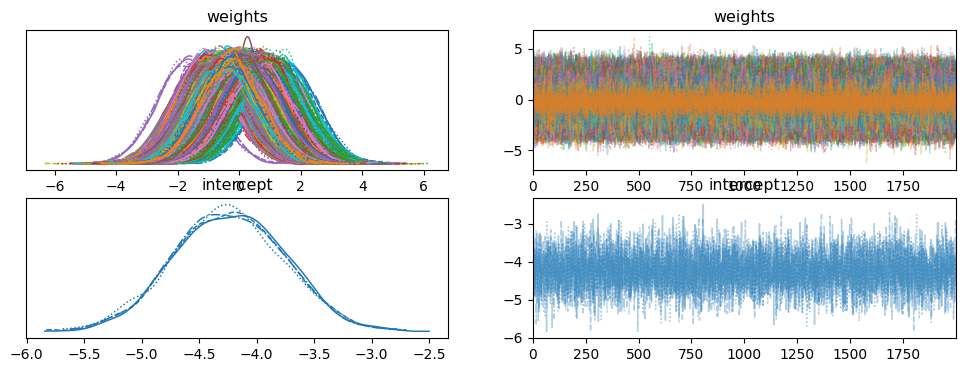

In [24]:
az.plot_trace(idata, var_names=['weights', 'intercept'])

### Posterior distribution for a single prediction

In [25]:
def plot_prediction(df_test):
    """
    Selects an instance at random from the calculated test observations and visualizes
    the probability distribution.
    """

    # Choose the index of the test instance you want to visualize
    test_instance_index = random.randrange(len(df_test))
    single_test_instance = df_test[test_instance_index].reshape(1, -1)

    with logistic_model:
        pm.set_data({'X_train': single_test_instance})
        posterior_predictive_single = pm.sample_posterior_predictive(idata, random_seed=42, var_names=['p'])

    # Extract the posterior predictive samples for the chosen instance
    posterior_probabilities_single = posterior_predictive_single.posterior_predictive['p'].values.flatten()

    # Calculate the 95% credible interval
    credible_interval = az.hdi(posterior_probabilities_single, hdi_prob=0.95)
    lower_bound = credible_interval[0]
    upper_bound = credible_interval[1]

    # true_category = df_test.loc[df_test['id'] == (test_instance_index + 1), 'category'].iat[0]

    # Create the visualization
    plt.figure(figsize=(8, 4.5))

    # Plot the decision threshold
    plt.axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')

    # Plot the 95% credible interval
    plt.axvline(lower_bound, color='red', linestyle='-', linewidth=1, label='95% Credible Interval')
    plt.axvline(upper_bound, color='red', linestyle='-', linewidth=1)
    plt.fill_betweenx(y=[0, plt.ylim()[1]], x1=lower_bound, x2=upper_bound, color='red', alpha=0.2)

    plt.hist(posterior_probabilities_single, bins=30, density=True, alpha=0.6, label='Posterior Predictive Distribution')

    # Add labels and title
    plt.xlabel('Probability of Being Relevant (Class 1)')
    plt.ylabel('Density')
    plt.title(f'Posterior Predictive Distribution for Test Instance {test_instance_index + 1}')
    # plt.title(f'True category: {true_category}')
    plt.legend()
    plt.grid(True)
    plt.show()

Sampling: []


Output()

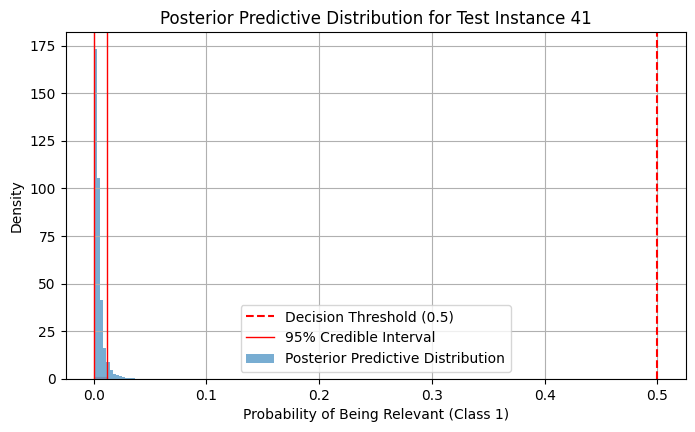

In [26]:
plot_prediction(X_test)

In [ ]:
# Choose the index of the test instance you want to visualize
# test_instance_index = random.randrange(len(X_test))
# single_test_instance = X_test[test_instance_index].reshape(1, -1)

# with logistic_model:
#     pm.set_data({'X_train': single_test_instance})
#     posterior_predictive_single = pm.sample_posterior_predictive(idata, random_seed=42, var_names=['p'])

# # Extract the posterior predictive samples for the chosen instance
# posterior_probabilities_single = posterior_predictive_single.posterior_predictive['p'].values.flatten()

# # Calculate the 95% credible interval
# credible_interval = az.hdi(posterior_probabilities_single, hdi_prob=0.95)
# lower_bound = credible_interval[0]
# upper_bound = credible_interval[1]

In [ ]:
# # Choose the index of the test instance you want to visualize
# test_instance_index = random.randrange(len(X_test))
# single_test_instance = X_test[test_instance_index].reshape(1, -1)

# with logistic_model:
#     pm.set_data({'X_train': single_test_instance})
#     posterior_predictive_single = pm.sample_posterior_predictive(idata, random_seed=42, var_names=['p'])

# # Extract the posterior predictive samples for the chosen instance
# posterior_probabilities_single = posterior_predictive_single.posterior_predictive['p'].values.flatten()

# # Calculate the 95% credible interval
# credible_interval = az.hdi(posterior_probabilities_single, hdi_prob=0.95)
# lower_bound = credible_interval[0]
# upper_bound = credible_interval[1]

In [ ]:
# # Create the visualization
# plt.figure(figsize=(8, 4.5))

# # Plot the decision threshold
# plt.axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')

# # Plot the 95% credible interval
# plt.axvline(lower_bound, color='red', linestyle='-', linewidth=1, label='95% Credible Interval')
# plt.axvline(upper_bound, color='red', linestyle='-', linewidth=1)
# plt.fill_betweenx(y=[0, plt.ylim()[1]], x1=lower_bound, x2=upper_bound, color='red', alpha=0.2)

# plt.hist(posterior_probabilities_single, bins=30, density=True, alpha=0.6, label='Posterior Predictive Distribution')

# # Add labels and title
# plt.xlabel('Probability of Being Relevant (Class 1)')
# plt.ylabel('Density')
# plt.title(f'Posterior Predictive Distribution for Test Instance {test_instance_index + 1}')
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# df.loc[df['id'] == (1537 + 1), 'category'].iat[0]

### Data set of prediction data for all test set observations

In [27]:
with logistic_model:
    pm.set_data({'X_train': X_test})
    posterior_predictive_all = pm.sample_posterior_predictive(idata, random_seed=42, var_names=['p'])

Sampling: []


Output()

In [28]:
posterior_probabilities_all = posterior_predictive_all.posterior_predictive['p'].values

In [29]:
prediction_data = []

for i in range(X_test.shape[0]):
    # get posterior probabilities for the current instance
    posterior_probs = posterior_probabilities_all[:, :, i].flatten()

    # calculate the 95% credible interval
    credible_interval = az.hdi(posterior_probs, hdi_prob=0.95)
    lower_bound = credible_interval[0]
    upper_bound = credible_interval[1]
    mean_probability = np.mean(posterior_probs)

    # store the data
    prediction_data.append({
        'doc_index': i,
        'posterior_samples': list(posterior_probs), # store the entire distribution
        'mean_probability': mean_probability,
        'ci_lower_bound': lower_bound,
        'ci_upper_bound': upper_bound,
        'ci_width': upper_bound - lower_bound,
        'true_label': y_test[i]
    })

predictions_df = pd.DataFrame(prediction_data)

In [30]:
predictions_df.head(3)

,doc_index,posterior_samples,mean_probability,ci_lower_bound,ci_upper_bound,ci_width,true_label
0,0,"[0.00926387081358758, 0.0019784158272490937, 0...",0.004875,0.000454,0.012508,0.012054,0
1,1,"[0.012748452643090151, 0.011976898215396384, 0...",0.011440,0.002125,0.025642,0.023516,0
2,2,"[0.01404897978217239, 0.0004450499346608218, 0...",0.002175,0.000123,0.005957,0.005833,0


In [31]:
glimpse(predictions_df)

Rows: 2263, Columns: 7

$doc_index <int64> 0, 1, 2, 3, 4
$posterior_samples <object> [np.float64(0.00926387081358758), np.float64(0.0019784158272490937), np.float...
$mean_probability <float64> 0.004875457949153601, 0.011440314713376896, 0.002174608356320406, 0.008969743...
$ci_lower_bound <float64> 0.0004541743660774913, 0.0021251557889643198, 0.0001234098527110399, 0.001069...
$ci_upper_bound <float64> 0.012508403027305862, 0.025641591807528633, 0.00595653587934023, 0.0205294057...
$ci_width <float64> 0.01205422866122837, 0.02351643601856431, 0.005833126026629189, 0.01945943016...
$true_label <int64> 0, 0, 0, 0, 0


In [32]:
mean_probability_by_label = predictions_df.groupby('true_label')['mean_probability'].mean()

In [33]:
mean_probability_by_label

true_label
0    0.021181
1    0.637908
Name: mean_probability, dtype: float64

In [34]:
summary_table = predictions_df.groupby('true_label').agg(
    mean_mean_prob = ('mean_probability', 'mean'),
    mean_lower_bound = ('ci_lower_bound', 'mean'),
    mean_upper_bound = ('ci_upper_bound', 'mean'),
    mean_ci_width = ('ci_width', 'mean'),
    sd_ci_width = ('ci_width', 'std')
).reset_index()

In [35]:
summary_table

,true_label,mean_mean_prob,mean_lower_bound,mean_upper_bound,mean_ci_width,sd_ci_width
0,0,0.021181,0.003897,0.046062,0.042165,0.068987
1,1,0.637908,0.454937,0.808678,0.353741,0.142987


In [36]:
predictions_df['pred_value'] = np.where(predictions_df['mean_probability'] >= 0.5, 1, 0)

In [37]:
predictions_df['pred_value'].value_counts()

pred_value
0    2179
1      84
Name: count, dtype: int64

In [ ]:
84/2179

In [ ]:
conditions = [predictions_df['ci_lower_bound'] >= 0.5,
              predictions_df['ci_upper_bound'] < 0.5]

vals = ['confident', 'confident']

predictions_df = predictions_df.assign(handling = np.select(conditions, vals, default='manual review'))

In [ ]:
predictions_df.sample(5)

In [ ]:
predictions_df['handling'].value_counts()

In [ ]:
61/2202

In [ ]:
predictions_df[predictions_df['handling'] == 'manual review']

In [ ]:
# predictions_df[predictions_df['ci_upper_bound'] < 0.664783]

Overall, the model's performance on the document embeddings I created resulted in an F-1 score of 0.83, which isn't bad. However, looking at this summary table, there doesn't seem to be a lot of difference between the distributions of documents that were irrelevant (true_label = 0) and documents that were relevant (true_label = 1).  

In [ ]:
# predictions_df[predictions_df['ci_lower_bound'] > 0.260486]

In [ ]:
az.plot_posterior(X_test[(test_instance_index + 1)])

In [ ]:
az.plot_posterior(X_test[(2190 + 1)])

In [ ]:
# reassembling test
pred_values = predictions_df['pred_value'].values
true_labels = predictions_df['true_label'].values
test_df = pd.DataFrame({'label': y_test, 'true_label': true_labels, 'category': cat_test, 'prediction': pred_values})

test_df

In [ ]:
true_labels == y_test

In [ ]:
(true_labels == y_test).astype(int).sum()

In [ ]:
predictions_df['category'] = cat_test

In [ ]:
predictions_df.head()

In [ ]:
predictions_df[predictions_df['handling'] == 'manual review']

In [ ]:
predictions_df[predictions_df['handling'] == 'manual review']['category'].value_counts()

In [ ]:
predictions_df.query('true_label != pred_value')['category'].value_counts()

In [ ]:
predictions_df.query('true_label != pred_value')['handling'].value_counts()

### Analyzing confidence interval

Distribution of `ci_width`

In [38]:
import seaborn as sns

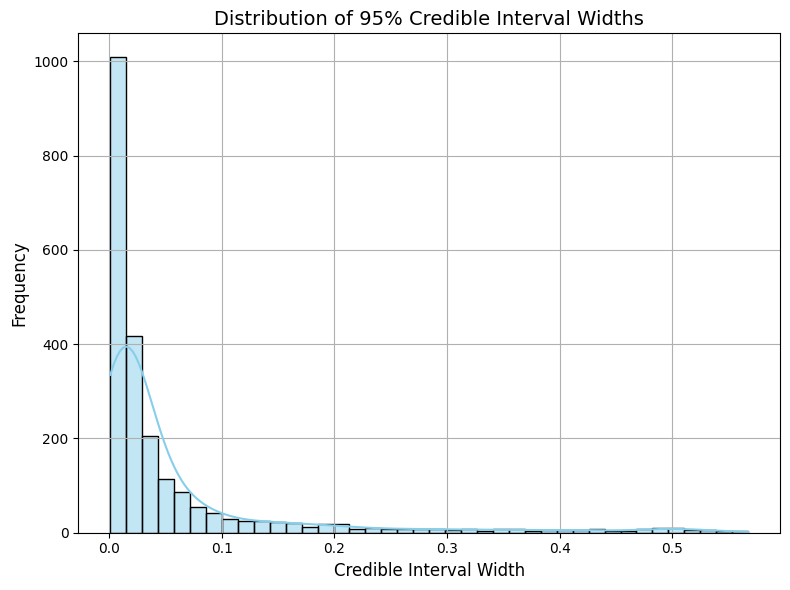

In [39]:
plt.figure(figsize=(8, 6))
sns.histplot(predictions_df['ci_width'], bins=40, kde=True, color='skyblue')

plt.title("Distribution of 95% Credible Interval Widths", fontsize=14)
plt.xlabel("Credible Interval Width", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

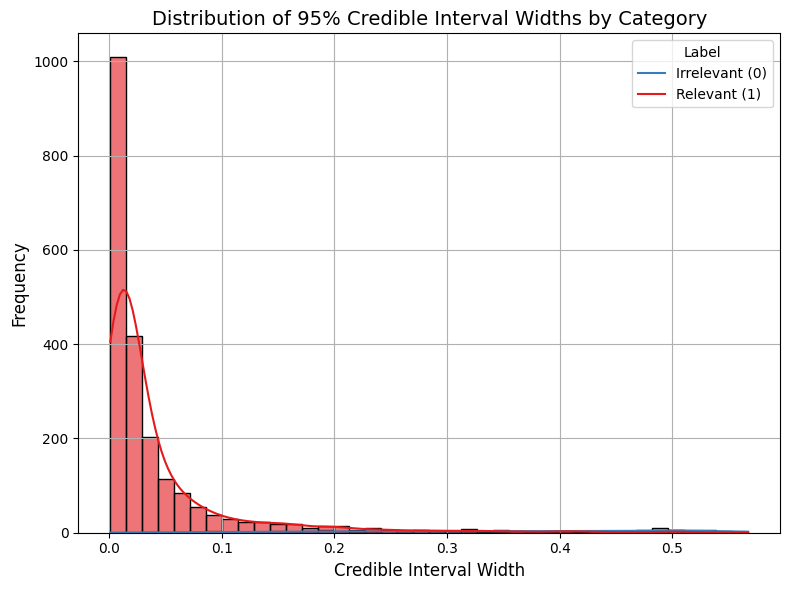

In [43]:
predictions_df['label_name'] = predictions_df['true_label'].map({0: 'Irrelevant', 1:'Relevant'})
plt.figure(figsize=(8, 6))
sns.histplot(data=predictions_df, x='ci_width', hue='label_name', bins=40, kde=True, palette='Set1', alpha=0.6)

plt.title("Distribution of 95% Credible Interval Widths by Category", fontsize=14)
plt.xlabel("Credible Interval Width", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title="Label", labels=["Irrelevant (0)", "Relevant (1)"])
plt.grid(True)
plt.tight_layout()
plt.show()

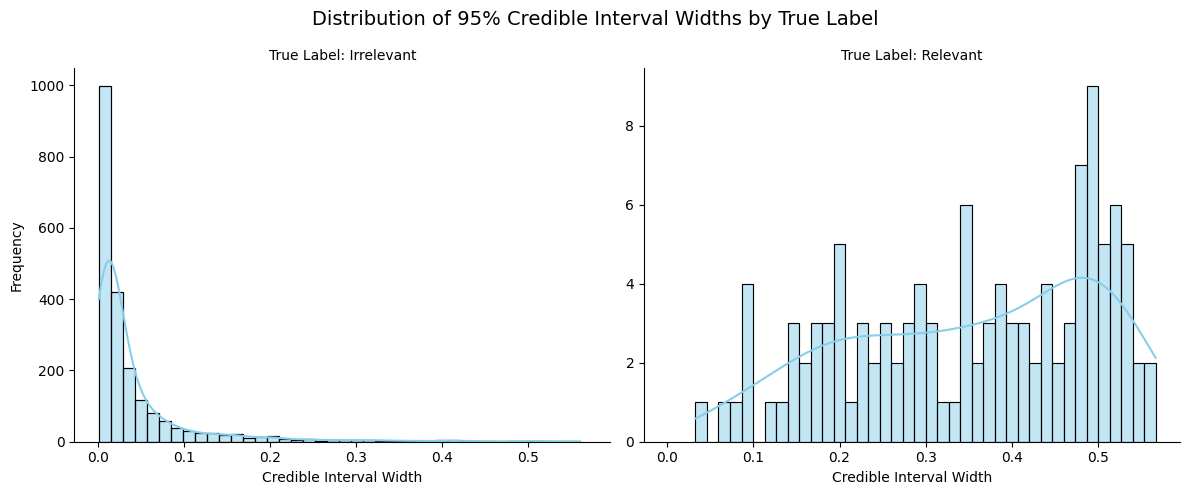

In [45]:
g = sns.FacetGrid(predictions_df, col='label_name', height=5, aspect=1.2, sharex=True, sharey=False)
g.map(sns.histplot, 'ci_width', bins=40, kde=True, color='skyblue')

g.set_axis_labels("Credible Interval Width", "Frequency")
g.set_titles("True Label: {col_name}")
plt.suptitle("Distribution of 95% Credible Interval Widths by True Label", fontsize=14)
plt.tight_layout()
plt.show()

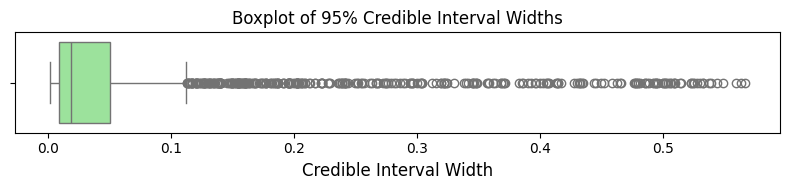

In [42]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=predictions_df['ci_width'], color='lightgreen')

plt.title("Boxplot of 95% Credible Interval Widths", fontsize=12)
plt.xlabel("Credible Interval Width", fontsize=12)
plt.tight_layout()
plt.show()

In [40]:
glimpse(predictions_df)

Rows: 2263, Columns: 8

$doc_index <int64> 0, 1, 2, 3, 4
$posterior_samples <object> [np.float64(0.00926387081358758), np.float64(0.0019784158272490937), np.float...
$mean_probability <float64> 0.004875457949153601, 0.011440314713376896, 0.002174608356320406, 0.008969743...
$ci_lower_bound <float64> 0.0004541743660774913, 0.0021251557889643198, 0.0001234098527110399, 0.001069...
$ci_upper_bound <float64> 0.012508403027305862, 0.025641591807528633, 0.00595653587934023, 0.0205294057...
$ci_width <float64> 0.01205422866122837, 0.02351643601856431, 0.005833126026629189, 0.01945943016...
$true_label <int64> 0, 0, 0, 0, 0
$pred_value <int64> 0, 0, 0, 0, 0


### Threshold Tuning

In [49]:
# define thresholds to evaluate
thresholds = np.linspace(0.05, 0.95, 19) # steps of 0.05
results = []

for thresh in thresholds:
    predicted_label = []
    review_flag = []

    for _, row in predictions_df.iterrows():
        if row['ci_lower_bound'] > thresh:
            predicted_label.append(1)
            review_flag.append(False)
        elif row['ci_lower_bound'] < thresh:
            predicted_label.append(0)
            review_flag.append(False)
        else:
            predicted_label.append(None) # flagging for manual review
            review_flag.append(True)
    
    # filter to auto-classified only
    auto_mask = [p is not None for p in predicted_label]
    y_true = predictions_df.loc[auto_mask, 'true_label']
    y_pred = [p for p in predicted_label if p is not None]

    # compute metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    manual_pct = 199 * np.mean(review_flag)

    results.append({
        'threshold': thresh,
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'manual_review_pct': manual_pct
    })

results_df = pd.DataFrame(results)

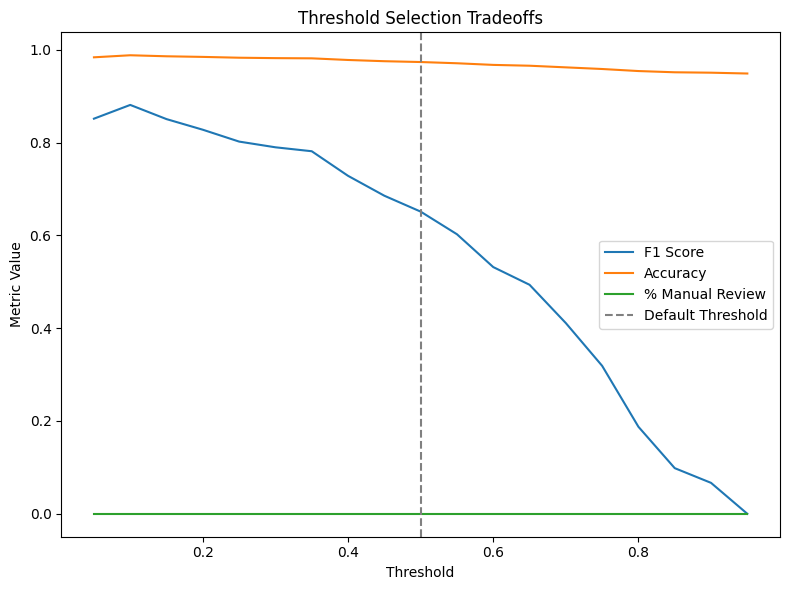

In [50]:
plt.figure(figsize=(8, 6))
sns.lineplot(data=results_df, x = 'threshold', y = 'f1', label='F1 Score')
sns.lineplot(data=results_df, x = 'threshold', y = 'accuracy', label='Accuracy')
sns.lineplot(data=results_df, x = 'threshold', y = 'manual_review_pct', label='% Manual Review')
plt.ylabel('Metric Value')
plt.xlabel('Threshold')
plt.title('Threshold Selection Tradeoffs')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold')
plt.legend()
plt.tight_layout()
plt.show()